In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("salaries.csv")
df.shape

(1000, 5)

In [3]:
df.head()

,Years of Experience,Education Level,Age,Location Factor,Salary
0,29,1,49,7,124204
1,27,3,45,4,125948
2,20,4,41,8,116078
3,14,4,37,5,106486
4,20,3,42,7,113297


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X = df.drop("Salary", axis=1)
y = df["Salary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_full = LinearRegression()
model_full.fit(X_train, y_train)
y_pred = model_full.predict(X_test)
model_full.score(X_test, y_test)

0.9594068613513749

In [5]:
model_full.intercept_, model_full.coef_

(np.float64(52519.18303688665),
 array([2109.51761869, 5060.61877537, -120.2791406 , 1495.70225789]))

In [7]:
X_test[:1]

,Years of Experience,Education Level,Age,Location Factor
521,15,3,37,5


In [8]:
y_test[:1]

521    97186
Name: Salary, dtype: int64

In [11]:
model_full.predict(X_test[:1])

array([102371.98673052])

In [10]:
predicted = model_full.intercept_ + model_full.coef_[0] * 15 + model_full.coef_[1] * 3 + model_full.coef_[2] * 37 + model_full.coef_[3] * 5
predicted

np.float64(102371.98673051775)

<Axes: xlabel='Age', ylabel='Salary'>

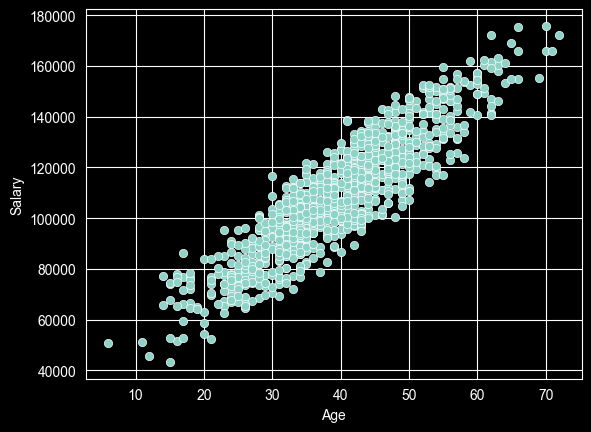

In [15]:
import  seaborn as sns
sns.scatterplot(df, x="Age", y="Salary")

## Here the model accuracy is very good but the coefficient value of age is conflicting with the actual scenario. Thats why we need to Implement VIF

<Axes: >

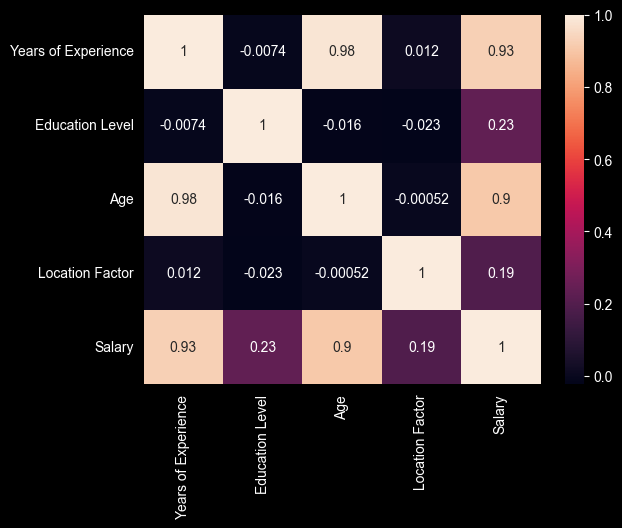

In [16]:
cm = df.corr()
sns.heatmap(cm, annot=True)

## Implement VIF

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [18]:
df.values

array([[    29,      1,     49,      7, 124204],
       [    27,      3,     45,      4, 125948],
       [    20,      4,     41,      8, 116078],
       ...,
       [    13,      3,     33,      8, 100478],
       [    19,      2,     40,      2, 100085],
       [    16,      2,     36,      9, 103222]], shape=(1000, 5))

In [19]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["Variable"] = data.columns
    vif_df["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

X = df.drop("Salary", axis=1)
calculate_vif(X)

,Variable,VIF
0,Years of Experience,22.342087
1,Education Level,5.472969
2,Age,42.201149
3,Location Factor,4.289467


In [20]:
calculate_vif(X.drop("Age", axis=1)) # As the VIF for age is higher

,Variable,VIF
0,Years of Experience,3.198601
1,Education Level,3.509425
2,Location Factor,3.231181


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X.drop("Age", axis=1), y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9592314656682582

In [22]:
model.coef_

array([1994.10983096, 5070.62814345, 1500.8453815 ])